# Experiment 1: NGRC Weight Analysis on the Lorenz System

## Objectives

- Generate Lorenz system data and train an NGRC model with $k = 1$.
- Extract and examine the learned NGRC weights.
- Identify the most influential linear and nonlinear features.
- Compare the learned terms with the Euler-discretized Lorenz equations.
- Investigate whether NGRC recovers the known dynamical structure of the Lorenz system.
- Visualize and interpret the dominant interactions governing the system dynamics.

In [32]:
# Source: LorenzConstLinQuadraticNVARtimedelay-RK23.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.integrate import solve_ivp

In [33]:
# Output directories

OUTPUT_DIR = Path("../outputs")

IMAGE_DIR = OUTPUT_DIR / "images" / "lrz63"
LOG_DIR = OUTPUT_DIR / "logs"

LOG_FILE = LOG_DIR / "analysis_report.txt"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

## Simulation and NVAR Parameters

### Function 1: Generate Lorenz data

In [34]:
def generate_lorenz_data(dt, maxtime):

    # Lorenz63 parameters
    sigma = 10
    rho = 28
    beta = 8 / 3

    # Initial condition
    initial_state = [17.67715816276679, 12.931379185960404, 43.91404334248268]

    # Time vector
    maxtime_pts = round(maxtime / dt)

    t_eval = np.linspace(0, maxtime, maxtime_pts + 1)

    # Lorenz63 equations
    def lorenz(t, state):

        x, y, z = state
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z

        return [dx, dy, dz]

    # Numerical integration
    lorenz_soln = solve_ivp(
        lorenz,
        (0, maxtime),
        initial_state,
        t_eval=t_eval,
        method="RK23",
    )

    return lorenz_soln

In [35]:
def build_ngrc_features(lorenz_soln, d, k):

    maxtime_pts = lorenz_soln.y.shape[1] - 1
    dlin = d * k

    x = np.zeros((dlin, maxtime_pts))

    for delay in range(k):
        for j in range(delay, maxtime_pts):

            x[d * delay:d * (delay + 1), j] = lorenz_soln.y[:, j - delay]

    return x

In [36]:
def train_ngrc(
    x,
    d,
    k,
    warmup_pts,
    warmtrain_pts,
    traintime_pts,
    ridge_param,
    total_var,
):

    dlin = d * k
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    # Training feature matrix
    out_train = np.ones((dtot, traintime_pts))

    out_train[1:dlin + 1, :] = x[:, warmup_pts - 1:warmtrain_pts - 1]

    cnt = 0

    for i in range(dlin):
        for j in range(i, dlin):

            out_train[dlin + 1 + cnt, :] = (
                x[i, warmup_pts - 1:warmtrain_pts - 1]
                * x[j, warmup_pts - 1:warmtrain_pts - 1]
            )

            cnt += 1

    # Training target
    Y = (
        x[0:d, warmup_pts:warmtrain_pts]
        - x[0:d, warmup_pts - 1:warmtrain_pts - 1]
    )

    # Ridge regression
    W_out = (
        Y @ out_train.T
        @ np.linalg.pinv(
            out_train @ out_train.T
            + ridge_param * np.identity(dtot)
        )
    )

    # Training prediction
    x_predict = (
        x[0:d, warmup_pts - 1:warmtrain_pts - 1]
        + W_out @ out_train
    )

    train_nrmse = np.sqrt(
        np.mean(
            (
                x[0:d, warmup_pts:warmtrain_pts]
                - x_predict
            ) ** 2
        ) / total_var
    )

    return W_out, train_nrmse

In [37]:
def predict_ngrc(
    x,
    W_out,
    d,
    k,
    warmtrain_pts,
    testtime_pts,
    lyaptime_pts,
    total_var,
):

    dlin = d * k
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    out_test = np.zeros(dtot)

    x_test = np.zeros((dlin, testtime_pts))
    x_test[:, 0] = x[:, warmtrain_pts - 1]

    for j in range(testtime_pts - 1):

        out_test[1:dlin + 1] = x_test[:, j]

        cnt = 0

        for row in range(dlin):
            for col in range(row, dlin):

                out_test[dlin + 1 + cnt] = (
                    x_test[row, j]
                    * x_test[col, j]
                )

                cnt += 1

        x_test[d:dlin, j + 1] = x_test[0:(dlin - d), j]

        x_test[0:d, j + 1] = (
            x_test[0:d, j]
            + W_out @ out_test
        )

    true_segment = x[
        0:d,
        warmtrain_pts - 1:warmtrain_pts + lyaptime_pts - 1,
    ]

    pred_segment = x_test[
        0:d,
        0:lyaptime_pts,
    ]

    test_nrmse = np.sqrt(
        np.mean(
            (true_segment - pred_segment) ** 2
        ) / total_var
    )

    return x_test, test_nrmse

In [38]:
def run_experiment(dt=0.025, ridge_param=2.5e-6, k=1):

    # Parameters
    warmup = 5.0
    traintime = 10.0
    testtime = 80.0
    lyaptime = 1.104

    maxtime = warmup + traintime + testtime

    # Time points
    warmup_pts = round(warmup / dt)
    traintime_pts = round(traintime / dt)
    warmtrain_pts = warmup_pts + traintime_pts
    testtime_pts = round(testtime / dt)
    lyaptime_pts = round(lyaptime / dt)
    
    print(f"Training points: {traintime_pts}")
    # NVAR dimensions
    d = 3

    # Generate Lorenz data
    lorenz_soln = generate_lorenz_data(dt, maxtime)

    total_var = np.var(lorenz_soln.y)

    # Build NGRC features
    x = build_ngrc_features(
        lorenz_soln,
        d,
        k,
    )

    # Train NGRC
    W_out, train_nrmse = train_ngrc(
        x,
        d,
        k,
        warmup_pts,
        warmtrain_pts,
        traintime_pts,
        ridge_param,
        total_var,
    )

    # Autonomous prediction
    x_test, test_nrmse = predict_ngrc(
        x,
        W_out,
        d,
        k,
        warmtrain_pts,
        testtime_pts,
        lyaptime_pts,
        total_var,
    )

    return {
        "dt": dt,
        "k": k,
        "ridge": ridge_param,
        "train_nrmse": train_nrmse,
        "test_nrmse": test_nrmse,
        "W_out": W_out,
        "x_test": x_test,

        "true_test": x[
            0:d,
            warmtrain_pts - 1:warmtrain_pts + testtime_pts - 1,
        ],
    }

In [39]:
def build_labels(d=3, k=1):

    variables = ["x", "y", "z"]

    linear_labels = []

    for delay in range(k):
        for var in variables:

            if delay == 0:
                linear_labels.append(f"{var}(t)")
            else:
                linear_labels.append(f"{var}(t-{delay})")

    labels = ["1"] + linear_labels

    for i in range(len(linear_labels)):
        for j in range(i, len(linear_labels)):
            labels.append(
                f"{linear_labels[i]}*{linear_labels[j]}"
            )

    return labels

In [40]:
d = 3
k = 1
ridge_param = 2.5e-6

labels = build_labels(d=d, k=k)

dt_values = [
    1e-1,
    5e-2,
    2.5e-2,
    1e-2,
    5e-3,
    2.5e-3,
    1e-3,
    5e-4,
    1e-4,
    5e-5,
    #1e-5,
    #5e-6,
    #1e-6,
]

results = []

for dt in dt_values:

    results.append(run_experiment(
        dt=dt,
        ridge_param=ridge_param,
        k=k,
    ))

    print(f"Completed dt={dt}")

print(f"Completed {len(results)} runs")

Training points: 100
Completed dt=0.1
Training points: 200
Completed dt=0.05
Training points: 400
Completed dt=0.025
Training points: 1000
Completed dt=0.01
Training points: 2000
Completed dt=0.005
Training points: 4000
Completed dt=0.0025
Training points: 10000
Completed dt=0.001
Training points: 20000
Completed dt=0.0005
Training points: 100000
Completed dt=0.0001
Training points: 200000
Completed dt=5e-05
Completed 10 runs


In [43]:
equations = ["dx", "dy", "dz"]

rows = []

for result in results:

    W = result["W_out"]

    for eq, equation in enumerate(equations):

        row = {
            "dt": result["dt"],
            "equation": equation,
            "train_nrmse": result["train_nrmse"],
            "test_nrmse": result["test_nrmse"],
        }

        for i, label in enumerate(labels):
            row[label] = W[eq, i]

        rows.append(row)

weights_df = pd.DataFrame(rows)

weights_df.head()

,dt,equation,train_nrmse,test_nrmse,1,x(t),y(t),z(t),x(t)*x(t),x(t)*y(t),x(t)*z(t),y(t)*y(t),y(t)*z(t),z(t)*z(t)
0,0.10,dx,0.116740,0.441163,-0.002492,-0.249609,1.035255,-0.017471,0.002535,-0.010449,-0.012611,0.006465,-0.020791,0.000317
1,0.10,dy,0.116740,0.441163,0.326097,0.520771,1.256160,-0.113333,0.002398,-0.032647,-0.015661,0.023527,-0.064649,0.002695
2,0.10,dz,0.116740,0.441163,-0.730313,-0.390959,0.298659,0.313098,0.138763,-0.178198,0.009457,0.120365,-0.010487,-0.022730
3,0.05,dx,0.026832,0.219567,0.105633,-0.195828,0.460708,-0.013710,-0.001105,0.000868,-0.006850,-0.000127,-0.003649,0.000343
4,0.05,dy,0.026832,0.219567,0.855094,0.705084,0.449861,-0.109731,-0.009142,0.007136,-0.024104,-0.000959,-0.023184,0.002788


In [44]:
weights_dx = weights_df[ weights_df["equation"] == "dx" ].copy()

# Convert NGRC coefficients to continuous-time form

weights_dx["NGRC x(t)/dt"] = weights_dx["x(t)"] / weights_dx["dt"]

weights_dx["NGRC y(t)/dt"] = weights_dx["y(t)"] / weights_dx["dt"]

# Analytical Lorenz coefficients

weights_dx["Lorenz x(t)"] = -10

weights_dx["Lorenz y(t)"] = 10

weights_dx[
    [
        "dt",
        "NGRC x(t)/dt",
        "Lorenz x(t)",
        "NGRC y(t)/dt",
        "Lorenz y(t)",
    ]
].head()

,dt,NGRC x(t)/dt,Lorenz x(t),NGRC y(t)/dt,Lorenz y(t)
0,0.100,-2.496087,-10,10.352551,10
3,0.050,-3.916559,-10,9.214168,10
6,0.025,-6.110286,-10,9.175140,10
9,0.010,-8.230818,-10,9.560165,10
12,0.005,-9.074172,-10,9.767808,10


In [45]:
weights_dx["x_error"] = np.abs(
    weights_dx["NGRC x(t)/dt"]
    - weights_dx["Lorenz x(t)"]
)

weights_dx["y_error"] = np.abs(
    weights_dx["NGRC y(t)/dt"]
    - weights_dx["Lorenz y(t)"]
)

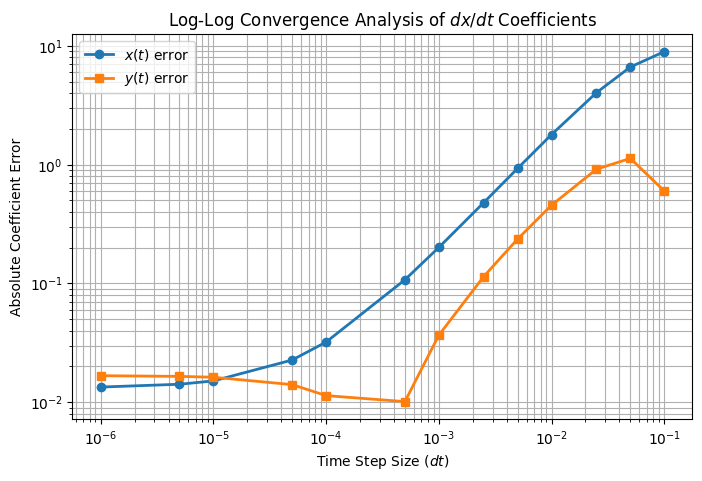

In [13]:
plt.figure(figsize=(8, 5))

plt.loglog(
    weights_dx["dt"],
    weights_dx["x_error"],
    marker="o",
    linewidth=2,
    label=r"$x(t)$ error",
)

plt.loglog(
    weights_dx["dt"],
    weights_dx["y_error"],
    marker="s",
    linewidth=2,
    label=r"$y(t)$ error",
)

plt.xlabel(r"Time Step Size ($dt$)")

plt.ylabel("Absolute Coefficient Error")

plt.title(
    r"Log-Log Convergence Analysis of $dx/dt$ Coefficients"
)

plt.grid(True, which="both")

plt.legend()

plt.savefig(
    f"{IMAGE_DIR}/convergence_log_dx_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

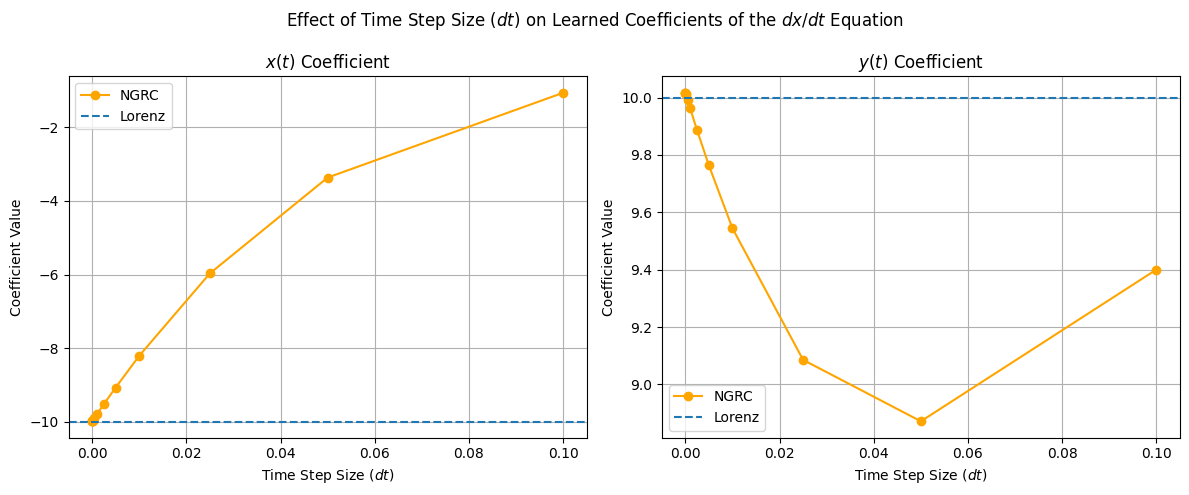

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharex=True,
)

# x coefficient

axes[0].plot(
    weights_dx["dt"],
    weights_dx["NGRC x(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[0].axhline(y=-10, linestyle="--", label="Lorenz")

axes[0].set_title(r"$x(t)$ Coefficient")

axes[0].set_xlabel(r"Time Step Size ($dt$)")

axes[0].set_ylabel("Coefficient Value")

axes[0].grid(True)

axes[0].legend()

# y coefficient

axes[1].plot(
    weights_dx["dt"],
    weights_dx["NGRC y(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[1].axhline(y=10, linestyle="--", label="Lorenz")

axes[1].set_title(r"$y(t)$ Coefficient")

axes[1].set_xlabel(r"Time Step Size ($dt$)")

axes[1].set_ylabel("Coefficient Value")

axes[1].grid(True)

axes[1].legend()

plt.suptitle(
    r"Effect of Time Step Size ($dt$) on Learned Coefficients of the $dx/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dx_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [15]:
weights_dx = weights_df[
    weights_df["equation"] == "dx"
].copy()

factor_cols = labels[1:]

rows = []

for _, row in weights_dx.iterrows():

    dt = row["dt"]

    coeffs = row[factor_cols] / dt

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": dt,

        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",

        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",

        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dx = pd.DataFrame(rows).sort_values("dt")

top3_dx

,dt,1st,2nd,3rd
12,0.000001,y(t) (10.02),x(t) (-9.99),z(t) (0.01)
11,0.000005,y(t) (10.02),x(t) (-9.99),z(t) (0.01)
10,0.000010,y(t) (10.02),x(t) (-9.98),z(t) (0.01)
9,0.000050,y(t) (10.01),x(t) (-9.98),z(t) (0.01)
8,0.000100,y(t) (10.01),x(t) (-9.97),z(t) (0.01)
7,0.000500,y(t) (9.99),x(t) (-9.89),z(t) (0.01)
6,0.001000,y(t) (9.96),x(t) (-9.80),z(t) (0.01)
5,0.002500,y(t) (9.89),x(t) (-9.52),x(t)*z(t) (-0.01)
4,0.005000,y(t) (9.76),x(t) (-9.07),x(t)*z(t) (-0.02)
3,0.010000,y(t) (9.54),x(t) (-8.21),x(t)*z(t) (-0.05)


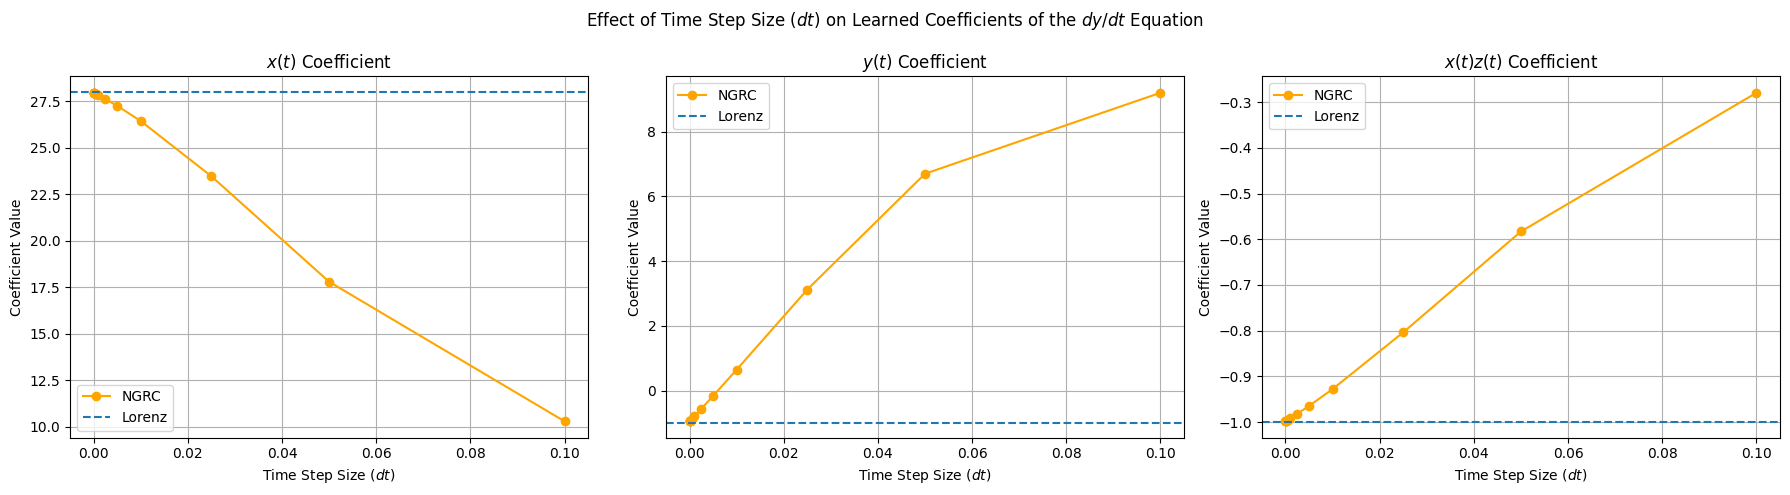

In [16]:
weights_dy = weights_df[
    weights_df["equation"] == "dy"
].copy()

# Convert NGRC coefficients to continuous-time form

weights_dy["NGRC x(t)/dt"] = weights_dy["x(t)"] / weights_dy["dt"]
weights_dy["NGRC y(t)/dt"] = weights_dy["y(t)"] / weights_dy["dt"]
weights_dy["NGRC x(t)*z(t)/dt"] = weights_dy["x(t)*z(t)"] / weights_dy["dt"]

# Analytical Lorenz coefficients

weights_dy["Lorenz x(t)"] = 28
weights_dy["Lorenz y(t)"] = -1
weights_dy["Lorenz x(t)*z(t)"] = -1

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# x coefficient

axes[0].plot(
    weights_dy["dt"],
    weights_dy["NGRC x(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[0].axhline(y=28, linestyle="--", label="Lorenz")
axes[0].set_title(r"$x(t)$ Coefficient")
axes[0].set_xlabel(r"Time Step Size ($dt$)")
axes[0].set_ylabel("Coefficient Value")
axes[0].grid(True)
axes[0].legend()

# y coefficient

axes[1].plot(
    weights_dy["dt"],
    weights_dy["NGRC y(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[1].axhline(y=-1, linestyle="--", label="Lorenz")
axes[1].set_title(r"$y(t)$ Coefficient")
axes[1].set_xlabel(r"Time Step Size ($dt$)")
axes[1].set_ylabel("Coefficient Value")
axes[1].grid(True)
axes[1].legend()

# xz coefficient

axes[2].plot(
    weights_dy["dt"],
    weights_dy["NGRC x(t)*z(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[2].axhline(y=-1, linestyle="--", label="Lorenz")
axes[2].set_title(r"$x(t)z(t)$ Coefficient")
axes[2].set_xlabel(r"Time Step Size ($dt$)")
axes[2].set_ylabel("Coefficient Value")
axes[2].grid(True)
axes[2].legend()

plt.suptitle(
    r"Effect of Time Step Size ($dt$) on Learned Coefficients of the $dy/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dy_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

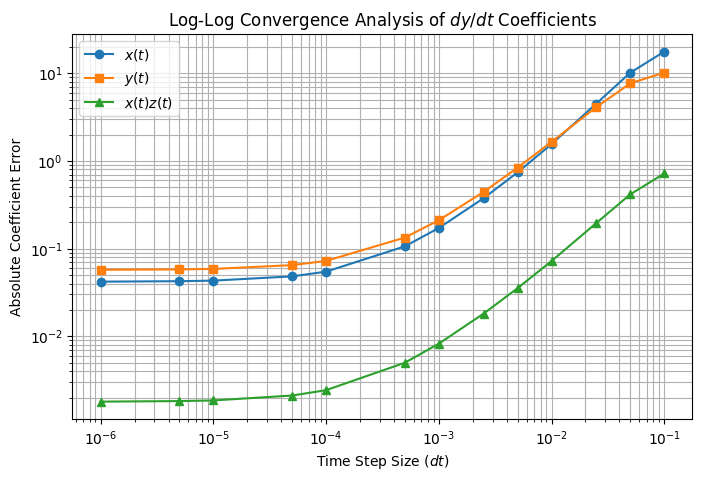

In [17]:
weights_dy["x_error"] = np.abs(
    weights_dy["NGRC x(t)/dt"] - 28
)

weights_dy["y_error"] = np.abs(
    weights_dy["NGRC y(t)/dt"] + 1
)

weights_dy["xz_error"] = np.abs(
    weights_dy["NGRC x(t)*z(t)/dt"] + 1
)

plt.figure(figsize=(8, 5))

plt.loglog(
    weights_dy["dt"],
    weights_dy["x_error"],
    marker="o",
    label=r"$x(t)$",
)

plt.loglog(
    weights_dy["dt"],
    weights_dy["y_error"],
    marker="s",
    label=r"$y(t)$",
)

plt.loglog(
    weights_dy["dt"],
    weights_dy["xz_error"],
    marker="^",
    label=r"$x(t)z(t)$",
)

plt.xlabel(r"Time Step Size ($dt$)")

plt.ylabel("Absolute Coefficient Error")

plt.title(
    r"Log-Log Convergence Analysis of $dy/dt$ Coefficients"
)

plt.grid(True, which="both")

plt.legend()

plt.savefig(
    f"{IMAGE_DIR}/convergence_log_dy_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [18]:
weights_dy = weights_df[
    weights_df["equation"] == "dy"
].copy()

factor_cols = labels[1:]

rows = []

for _, row in weights_dy.iterrows():

    dt = row["dt"]

    coeffs = row[factor_cols] / dt

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": dt,

        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",

        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",

        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dy = pd.DataFrame(rows).sort_values("dt")

top3_dy

,dt,1st,2nd,3rd
12,0.000001,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
11,0.000005,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
10,0.000010,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
9,0.000050,x(t) (27.95),x(t)*z(t) (-1.00),y(t) (-0.94)
8,0.000100,x(t) (27.95),x(t)*z(t) (-1.00),y(t) (-0.93)
7,0.000500,x(t) (27.89),x(t)*z(t) (-1.00),y(t) (-0.87)
6,0.001000,x(t) (27.83),x(t)*z(t) (-0.99),y(t) (-0.79)
5,0.002500,x(t) (27.62),x(t)*z(t) (-0.98),y(t) (-0.56)
4,0.005000,x(t) (27.26),x(t)*z(t) (-0.96),y(t) (-0.16)
3,0.010000,x(t) (26.44),x(t)*z(t) (-0.93),y(t) (0.65)


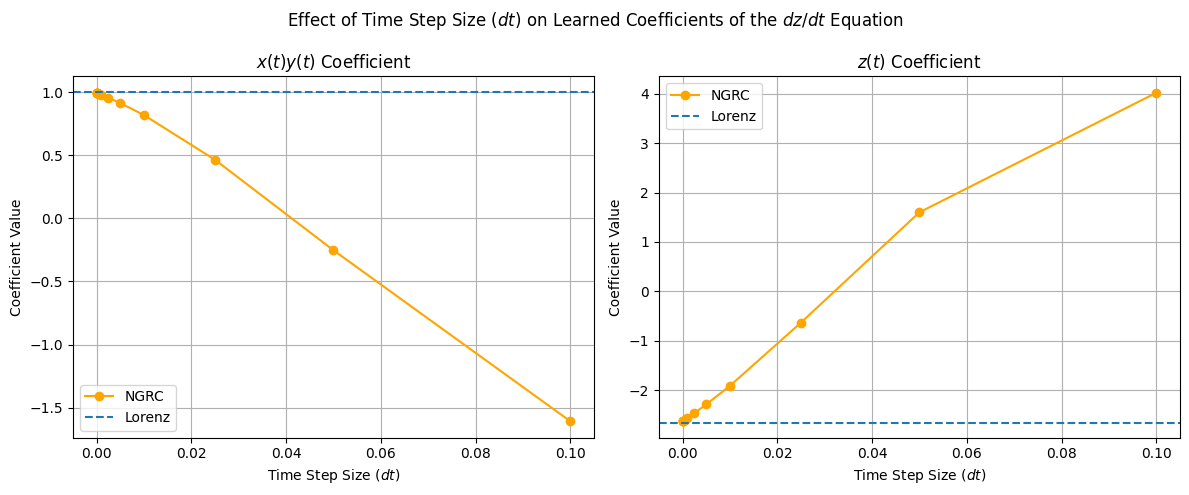

In [19]:
weights_dz = weights_df[
    weights_df["equation"] == "dz"
].copy()

# Convert NGRC coefficients to continuous-time form

weights_dz["NGRC x(t)*y(t)/dt"] = weights_dz["x(t)*y(t)"] / weights_dz["dt"]

weights_dz["NGRC z(t)/dt"] = weights_dz["z(t)"] / weights_dz["dt"]

# Analytical Lorenz coefficients

weights_dz["Lorenz x(t)*y(t)"] = 1

weights_dz["Lorenz z(t)"] = -(8 / 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# xy coefficient

axes[0].plot(
    weights_dz["dt"],
    weights_dz["NGRC x(t)*y(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[0].axhline(y=1, linestyle="--", label="Lorenz")

axes[0].set_title(r"$x(t)y(t)$ Coefficient")

axes[0].set_xlabel(r"Time Step Size ($dt$)")

axes[0].set_ylabel("Coefficient Value")

axes[0].grid(True)

axes[0].legend()

# z coefficient

axes[1].plot(
    weights_dz["dt"],
    weights_dz["NGRC z(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[1].axhline(y=-(8 / 3), linestyle="--", label="Lorenz")

axes[1].set_title(r"$z(t)$ Coefficient")

axes[1].set_xlabel(r"Time Step Size ($dt$)")

axes[1].set_ylabel("Coefficient Value")

axes[1].grid(True)

axes[1].legend()

plt.suptitle(
    r"Effect of Time Step Size ($dt$) on Learned Coefficients of the $dz/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dz_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

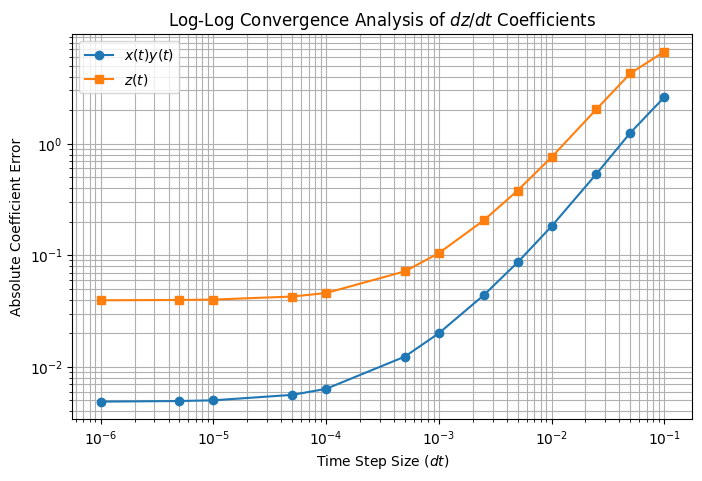

In [20]:
weights_dz["xy_error"] = np.abs(
    weights_dz["NGRC x(t)*y(t)/dt"] - 1
)

weights_dz["z_error"] = np.abs(
    weights_dz["NGRC z(t)/dt"] + (8 / 3)
)

plt.figure(figsize=(8, 5))

plt.loglog(
    weights_dz["dt"],
    weights_dz["xy_error"],
    marker="o",
    label=r"$x(t)y(t)$",
)

plt.loglog(
    weights_dz["dt"],
    weights_dz["z_error"],
    marker="s",
    label=r"$z(t)$",
)

plt.xlabel(r"Time Step Size ($dt$)")

plt.ylabel("Absolute Coefficient Error")

plt.title(
    r"Log-Log Convergence Analysis of $dz/dt$ Coefficients"
)

plt.grid(True, which="both")

plt.legend()

plt.savefig(
    f"{IMAGE_DIR}/convergence_log_dz_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [21]:
weights_dz = weights_df[
    weights_df["equation"] == "dz"
].copy()

factor_cols = labels[1:]

rows = []

for _, row in weights_dz.iterrows():

    dt = row["dt"]

    coeffs = row[factor_cols] / dt

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": dt,

        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",

        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",

        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dz = pd.DataFrame(rows).sort_values("dt")

top3_dz

,dt,1st,2nd,3rd
12,0.000001,z(t) (-2.63),x(t)*y(t) (1.00),y(t)*y(t) (0.00)
11,0.000005,z(t) (-2.63),x(t)*y(t) (1.00),y(t)*y(t) (0.00)
10,0.000010,z(t) (-2.63),x(t)*y(t) (0.99),y(t)*y(t) (0.00)
9,0.000050,z(t) (-2.62),x(t)*y(t) (0.99),y(t)*y(t) (0.00)
8,0.000100,z(t) (-2.62),x(t)*y(t) (0.99),y(t)*y(t) (0.00)
7,0.000500,z(t) (-2.59),x(t)*y(t) (0.99),x(t) (0.01)
6,0.001000,z(t) (-2.56),x(t)*y(t) (0.98),x(t) (0.02)
5,0.002500,z(t) (-2.46),x(t)*y(t) (0.96),x(t) (0.05)
4,0.005000,z(t) (-2.29),x(t)*y(t) (0.91),x(t) (0.11)
3,0.010000,z(t) (-1.91),x(t)*y(t) (0.82),x(t) (0.21)


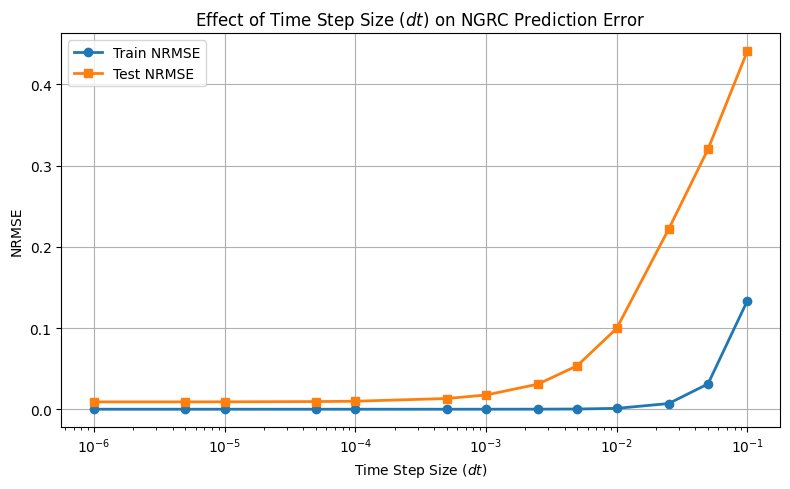

In [22]:
summary = pd.DataFrame([
    {
        "dt": r["dt"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }
    for r in results
])

summary = summary.sort_values("dt")

plt.figure(figsize=(8, 5))

plt.plot(
    summary["dt"],
    summary["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.plot(
    summary["dt"],
    summary["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xscale("log")

plt.xlabel(r"Time Step Size ($dt$)")

plt.ylabel("NRMSE")

plt.title(
    r"Effect of Time Step Size ($dt$) on NGRC Prediction Error"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [23]:
def euler_predict(x0, dt, testtime_pts, sigma=10, beta=8/3, rho=28):
    d = len(x0)
    x_euler = np.zeros((d, testtime_pts))
    x_euler[:, 0] = x0

    for j in range(testtime_pts - 1):
        x_now, y_now, z_now = x_euler[:, j]
        dx = sigma * (y_now - x_now)
        dy = x_now * (rho - z_now) - y_now
        dz = x_now * y_now - beta * z_now

        x_euler[0, j + 1] = x_now + dt * dx
        x_euler[1, j + 1] = y_now + dt * dy
        x_euler[2, j + 1] = z_now + dt * dz

    return x_euler

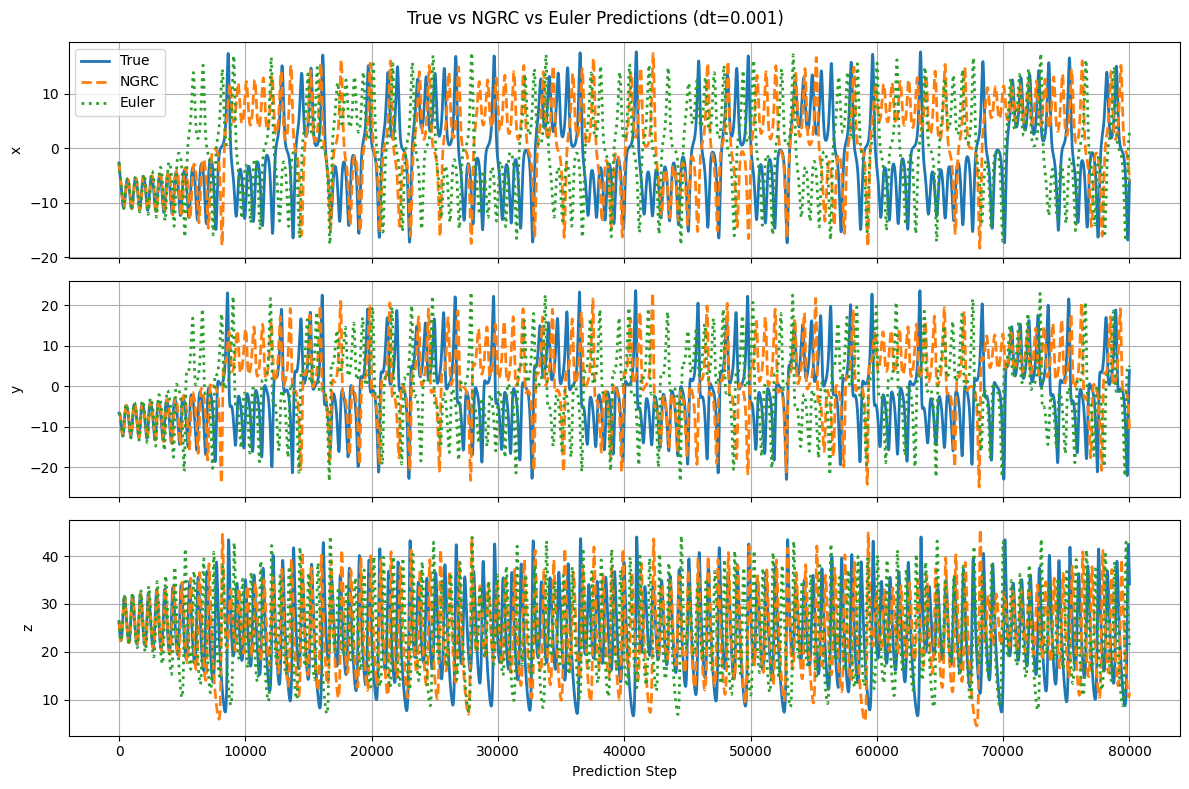

In [24]:


r = next(
    r for r in results
    if r["dt"] == 0.001
)

true = r["true_test"]

pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = pred_ngrc.shape[1]

fig, axs = plt.subplots(
    3,
    1,
    figsize=(12, 8),
    sharex=True,
)

names = ["x", "y", "z"]

for i in range(3):

    axs[i].plot(
        true[i, :n],
        linewidth=2,
        label="True",
    )

    axs[i].plot(
        pred_ngrc[i, :n],
        "--",
        linewidth=2,
        label="NGRC",
    )

    axs[i].plot(
        x_euler[i, :n],
        ":",
        linewidth=2,
        label="Euler",
    )

    axs[i].set_ylabel(names[i])

    axs[i].grid(True)

axs[0].legend()

axs[-1].set_xlabel("Prediction Step")

plt.suptitle(
    f"True vs NGRC vs Euler Predictions (dt={r['dt']})"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/true_vs_ngrc_vs_euler.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

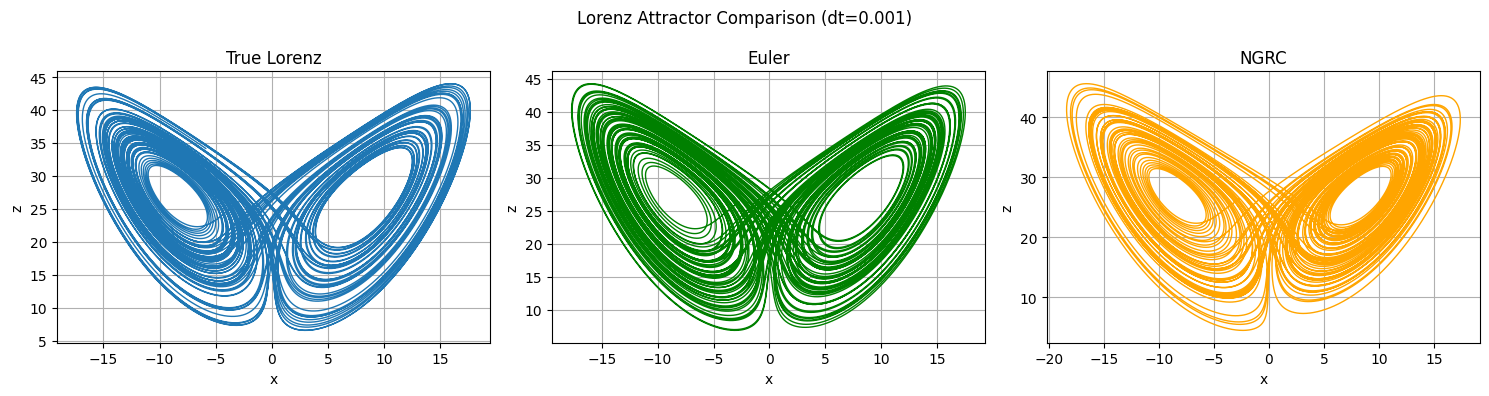

In [25]:
r = next(
    r for r in results
    if r["dt"] == 0.001
)

true = r["true_test"]

pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = pred_ngrc.shape[1]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# True Lorenz

axs[0].plot(
    true[0, :n],
    true[2, :n],
    linewidth=1,
)

axs[0].set_title("True Lorenz")

axs[0].set_xlabel("x")

axs[0].set_ylabel("z")

axs[0].grid(True)

# Euler

axs[1].plot(
    x_euler[0, :n],
    x_euler[2, :n],
    linewidth=1,
    color="green",
)

axs[1].set_title("Euler")

axs[1].set_xlabel("x")

axs[1].set_ylabel("z")

axs[1].grid(True)

# NGRC

axs[2].plot(
    pred_ngrc[0, :n],
    pred_ngrc[2, :n],
    linewidth=1,
    color="orange",
)

axs[2].set_title("NGRC")

axs[2].set_xlabel("x")

axs[2].set_ylabel("z")

axs[2].grid(True)

plt.suptitle(
    f"Lorenz Attractor Comparison (dt={r['dt']})"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/lorenz_attractor_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

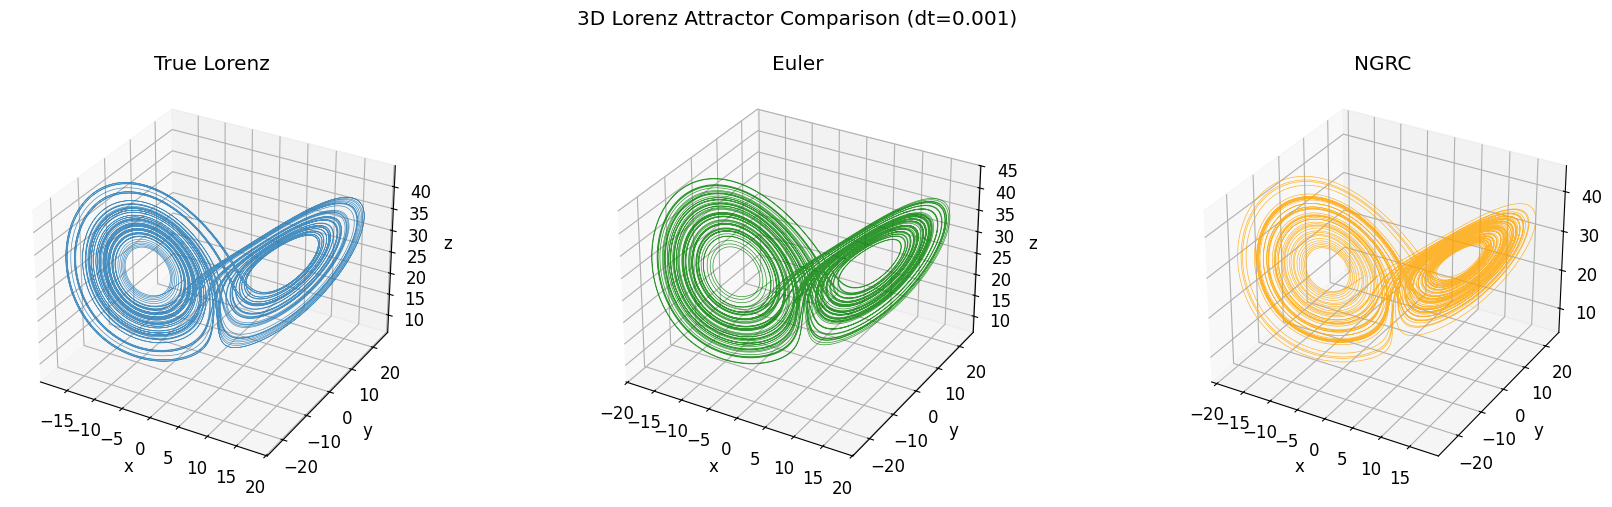

In [26]:
plt.rcParams.update({"font.size": 12})

r = next(
    r for r in results
    if r["dt"] == 0.001
)

true = r["true_test"]

pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = pred_ngrc.shape[1]

fig = plt.figure(figsize=(18, 5))

# True Lorenz

ax1 = fig.add_subplot(131, projection="3d")

ax1.plot(
    true[0, :n],
    true[1, :n],
    true[2, :n],
    linewidth=0.5,
    alpha=0.8,
)

ax1.set_title("True Lorenz")

ax1.set_xlabel("x")

ax1.set_ylabel("y")

ax1.set_zlabel("z")

# Euler

ax2 = fig.add_subplot(132, projection="3d")

ax2.plot(
    x_euler[0, :n],
    x_euler[1, :n],
    x_euler[2, :n],
    linewidth=0.5,
    alpha=0.8,
    color="green",
)

ax2.set_title("Euler")

ax2.set_xlabel("x")

ax2.set_ylabel("y")

ax2.set_zlabel("z")

# NGRC

ax3 = fig.add_subplot(133, projection="3d")

ax3.plot(
    pred_ngrc[0, :n],
    pred_ngrc[1, :n],
    pred_ngrc[2, :n],
    linewidth=0.5,
    alpha=0.8,
    color="orange",
)

ax3.set_title("NGRC")

ax3.set_xlabel("x")

ax3.set_ylabel("y")

ax3.set_zlabel("z")

plt.suptitle(
    f"3D Lorenz Attractor Comparison (dt={r['dt']})"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/lorenz_attractor_3d_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [27]:
d = 3

k = 1

dt = 0.01

labels = build_labels(d=d, k=k)

ridge_values = [
    0,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10,
    100,
]

results_ridge = []

for ridge in ridge_values:

    results_ridge.append(
        run_experiment(
            dt=dt,
            ridge_param=ridge,
            k=k,
        )
    )

    print(f"Completed ridge={ridge}")

summary_ridge = pd.DataFrame([
    {
        "ridge": r["ridge"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }
    for r in results_ridge
])

summary_ridge

Training points: 2500
Completed ridge=0
Training points: 2500
Completed ridge=1e-08
Training points: 2500
Completed ridge=1e-07
Training points: 2500
Completed ridge=1e-06
Training points: 2500
Completed ridge=1e-05
Training points: 2500
Completed ridge=0.0001
Training points: 2500
Completed ridge=0.001
Training points: 2500
Completed ridge=0.01
Training points: 2500
Completed ridge=0.1
Training points: 2500
Completed ridge=1
Training points: 2500
Completed ridge=10
Training points: 2500
Completed ridge=100


,ridge,train_nrmse,test_nrmse
0,0.000000e+00,0.001052,0.099508
1,1.000000e-08,0.001052,0.099508
2,1.000000e-07,0.001052,0.099508
3,1.000000e-06,0.001052,0.099508
4,1.000000e-05,0.001052,0.099508
5,1.000000e-04,0.001052,0.099508
6,1.000000e-03,0.001052,0.099507
7,1.000000e-02,0.001052,0.099494
8,1.000000e-01,0.001052,0.099370
9,1.000000e+00,0.001052,0.098169


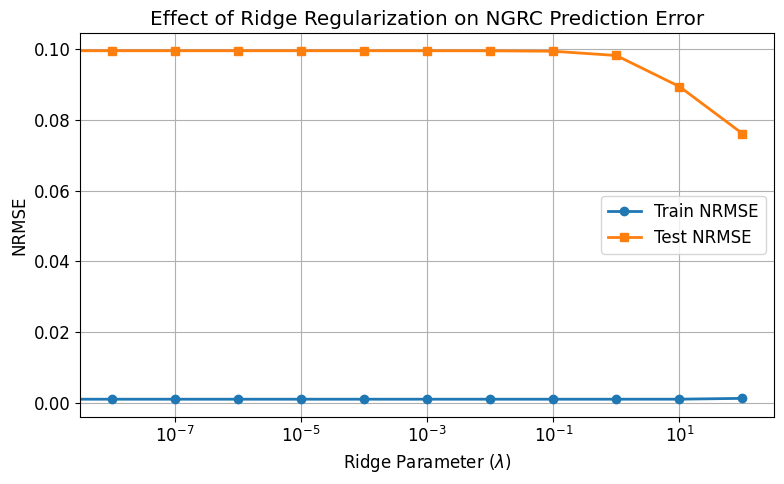

In [28]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xlabel(r"Ridge Parameter ($\lambda$)")

plt.ylabel("NRMSE")

plt.title(
    r"Effect of Ridge Regularization on NGRC Prediction Error"
)

plt.grid(True, which="both")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_ridge.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()